# Practice: VAE and CVAE on MNIST

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jen1995/my_blog/blob/main/notebooks/vae.ipynb)

This notebook is a hands-on companion to the post [Variational Autoencoder (VAE)](https://jen1995.github.io/my_blog/posts/vae/). We will build a VAE from scratch, train it on MNIST, and reproduce with our own hands all the key pictures of the post: reconstructions, samples from the prior, the latent space map and the learned manifold. Then we will add conditioning on the digit class and get a CVAE.

Everything runs on a CPU in a few minutes — no GPU needed.

What we will need:

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")

## Data

We take MNIST as is: $28 \times 28$ images with intensities in $[0, 1]$, flattened into vectors of length $784$.

In [2]:
transform = transforms.ToTensor()  # (1, 28, 28), values in [0, 1]

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)

print(f"train set: {len(train_ds)}, test set: {len(test_ds)}")

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

train set: 60000, test set: 10000


## Model

We build exactly what the post describes.

**Encoder** $q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$ with a diagonal covariance matrix: from an image, the network outputs the vector of means $\mu$ and the log-variances $\log \sigma^2$. Logs — so that we do not have to worry about positivity: $\sigma^2 = \exp(\log \sigma^2) > 0$ automatically.

**Reparameterization**: $z = \mu_\phi(x) + \varepsilon \cdot \sigma_\phi(x)$, where $\varepsilon \sim \mathcal{N}(0, I)$. The randomness lives in $\varepsilon$, while the gradients flow through $\mu$ and $\sigma$.

**Decoder** $p_\theta(x \mid z) = \operatorname{Bernoulli}(f_\theta(z))$: we treat the pixel intensity as the parameter of a Bernoulli distribution. The network outputs logits, and a sigmoid turns them into probabilities.

We write the class with an optional `cond_dim` right away — then the same implementation will also work for the CVAE (where the class label is additionally fed to the encoder and decoder).

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim, cond_dim=0, hidden=512):
        super().__init__()
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

        # encoder: (x, y) -> mu, log sigma^2
        self.encoder = nn.Sequential(
            nn.Linear(784 + cond_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * latent_dim),
        )
        # decoder: (z, y) -> Bernoulli logits for 784 pixels
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 784),
        )

    def encode(self, x, y=None):
        h = x if y is None else torch.cat([x, y], dim=1)
        mu, logvar = self.encoder(h).chunk(2, dim=1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y=None):
        h = z if y is None else torch.cat([z, y], dim=1)
        return self.decoder(h)  # logits

    def forward(self, x, y=None):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

## Loss function

We minimize $-\text{ELBO}$, i.e. the sum of the two terms from the post.

**Reconstruction loss.** For a Bernoulli decoder

$$-\log p_\theta(x \mid z) = -\sum_{j=1}^{784} \big( x_j \log p_j + (1 - x_j) \log (1 - p_j) \big),$$

that is, the usual binary cross-entropy summed over pixels.

**Regularization term.** For $q_\phi(z \mid x) = \mathcal{N}(\mu, \operatorname{diag}(\sigma^2))$ and $p(z) = \mathcal{N}(0, I)$ the KL divergence has a closed form:

$$D_{KL} = \frac{1}{2} \sum_{j=1}^{M} \big( \sigma_j^2 + \mu_j^2 - 1 - \ln \sigma_j^2 \big).$$

We will need the `beta` coefficient in front of the KL for the exercises: with `beta=1` this is the honest ELBO, with `beta=0` — a plain autoencoder.

Note that the number of $z$ samples per object is one — the post explains why this is enough when the batch is large.

In [4]:
def elbo_loss(logits, x, mu, logvar, beta=1.0):
    # reconstruction loss: BCE summed over pixels
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(dim=1)
    # KL(N(mu, sigma^2) || N(0, I)) in closed form
    kl = 0.5 * (mu.pow(2) + logvar.exp() - 1.0 - logvar).sum(dim=1)
    loss = (recon + beta * kl).mean()
    return loss, recon.mean(), kl.mean()

The training loop is completely ordinary: that very "setup typical for SGD" the post mentions right after the reparameterization trick.

In [5]:
def train(model, epochs=10, beta=1.0, conditional=False, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, epochs + 1):
        model.train()
        sums = np.zeros(3)
        n = 0
        for xb, yb in train_loader:
            x = xb.view(xb.size(0), -1).to(device)
            y = F.one_hot(yb, 10).float().to(device) if conditional else None

            logits, mu, logvar = model(x, y)
            loss, recon, kl = elbo_loss(logits, x, mu, logvar, beta)

            opt.zero_grad()
            loss.backward()
            opt.step()

            bs = x.size(0)
            sums += np.array([loss.item(), recon.item(), kl.item()]) * bs
            n += bs

        loss_, recon_, kl_ = sums / n
        print(f"epoch {epoch:2d} | -ELBO {loss_:7.2f} | recon {recon_:7.2f} | KL {kl_:6.2f}")
    return model

A couple of helper functions for pictures:

In [6]:
def show_grid(imgs, nrow, ncol, title=None, figsize=(8, 4)):
    """imgs: a (nrow*ncol, 784) tensor with values in [0, 1]"""
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize)
    for ax, img in zip(np.array(axes).flat, imgs):
        ax.imshow(img.view(28, 28).detach().numpy(), cmap="gray")
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def sample_from_prior(model, n=16, label=None):
    """Sample z ~ N(0, I) and pass it through the decoder."""
    model.eval()
    z = torch.randn(n, model.latent_dim)
    y = None
    if label is not None:
        y = F.one_hot(torch.full((n,), label), 10).float()
    return torch.sigmoid(model.decode(z, y))

## VAE with a two-dimensional latent space

We start with $M = 2$: such a latent space is easy to visualize in full — this is exactly how the pictures in the post were made.

In [7]:
vae2 = VAE(latent_dim=2).to(device)
train(vae2, epochs=10)

epoch  1 | -ELBO  199.97 | recon  193.92 | KL   6.04


epoch  2 | -ELBO  172.81 | recon  167.52 | KL   5.29


epoch  3 | -ELBO  166.21 | recon  160.89 | KL   5.31


epoch  4 | -ELBO  162.94 | recon  157.52 | KL   5.42


epoch  5 | -ELBO  160.90 | recon  155.41 | KL   5.49


...

epoch  7 | -ELBO  158.21 | recon  152.63 | KL   5.58


epoch  8 | -ELBO  157.28 | recon  151.66 | KL   5.63


epoch  9 | -ELBO  156.47 | recon  150.81 | KL   5.66


epoch 10 | -ELBO  155.80 | recon  150.11 | KL   5.69


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=784, bias=True)
  )
)

### Reconstructions

Let us pass test images through the encoder and decoder. The top row shows the originals, the bottom one — what the model reconstructed from the latent code.

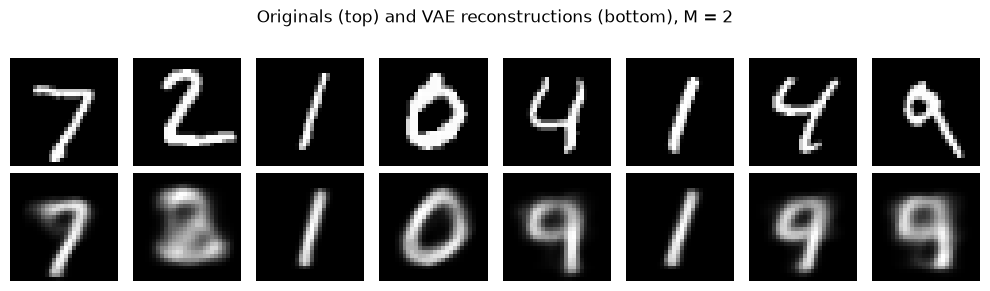

In [8]:
x_test = next(iter(test_loader))[0][:8].view(8, -1)

with torch.no_grad():
    vae2.eval()
    logits, _, _ = vae2(x_test)
    recon = torch.sigmoid(logits)

show_grid(torch.cat([x_test, recon]), nrow=2, ncol=8,
          title="Originals (top) and VAE reconstructions (bottom), M = 2", figsize=(10, 3))

### Samples from the prior

The encoder is no longer needed here: we take $z \sim \mathcal{N}(0, I)$ and feed it straight into the decoder. This is exactly how a trained VAE generates.

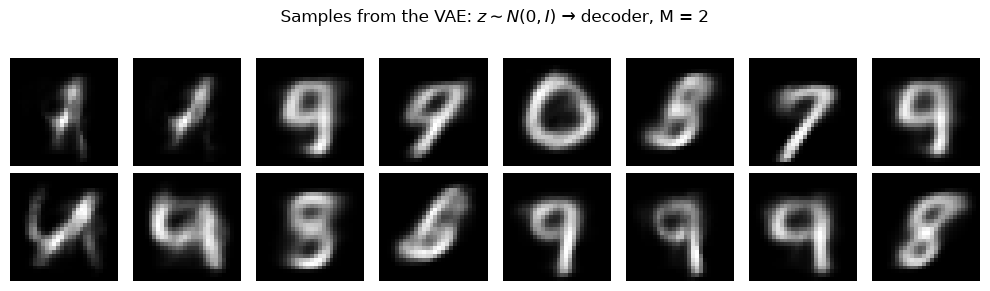

In [9]:
show_grid(sample_from_prior(vae2, n=16), nrow=2, ncol=8,
          title="Samples from the VAE: $z \\sim N(0, I)$ → decoder, M = 2", figsize=(10, 3))

The digits are recognizable but blurry — precisely the blurriness discussed in the box about conditional independence of pixels.

### Latent space map

Let us encode the entire test set and see where the codes of different digit classes land. This reproduces the picture from the post about the distribution of MNIST latent codes.

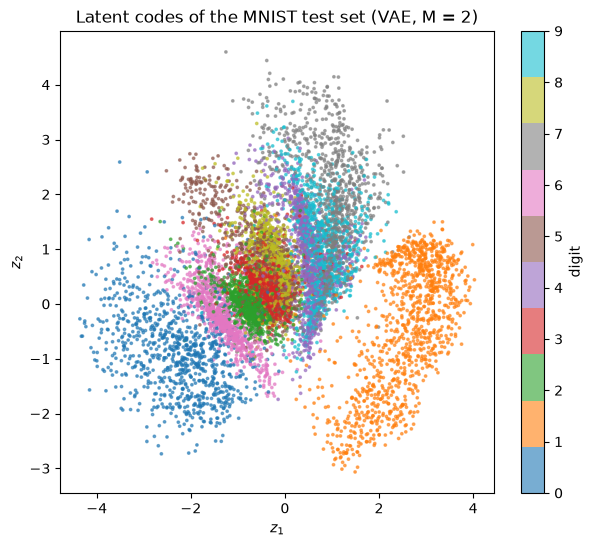

In [10]:
@torch.no_grad()
def latent_scatter(model, conditional=False, title=""):
    model.eval()
    codes, labels = [], []
    for xb, yb in test_loader:
        x = xb.view(xb.size(0), -1)
        y = F.one_hot(yb, 10).float() if conditional else None
        mu, _ = model.encode(x, y)
        codes.append(mu)
        labels.append(yb)
    z = torch.cat(codes).numpy()
    y = torch.cat(labels).numpy()

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(z[:, 0], z[:, 1], c=y, cmap="tab10", s=3, alpha=0.6)
    plt.colorbar(sc, ticks=range(10), label="digit")
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.title(title)
    plt.show()


latent_scatter(vae2, title="Latent codes of the MNIST test set (VAE, M = 2)")

Look at which classes the model has placed far apart and which it has confused. The post notes that zeros and ones separate best, while threes and eights are the hardest — compare with your own picture.

### The learned manifold

That very technique from the post: we take a uniform grid on the square $[0,1]^2$ and apply $\Phi^{-1}$ — the inverse CDF of the standard normal distribution. The resulting points are approximately distributed as $\mathcal{N}(0, I)$, i.e. they cover the prior "fairly". All that remains is to pass them through the decoder.

In PyTorch, $\Phi^{-1}$ is `torch.special.ndtri`.

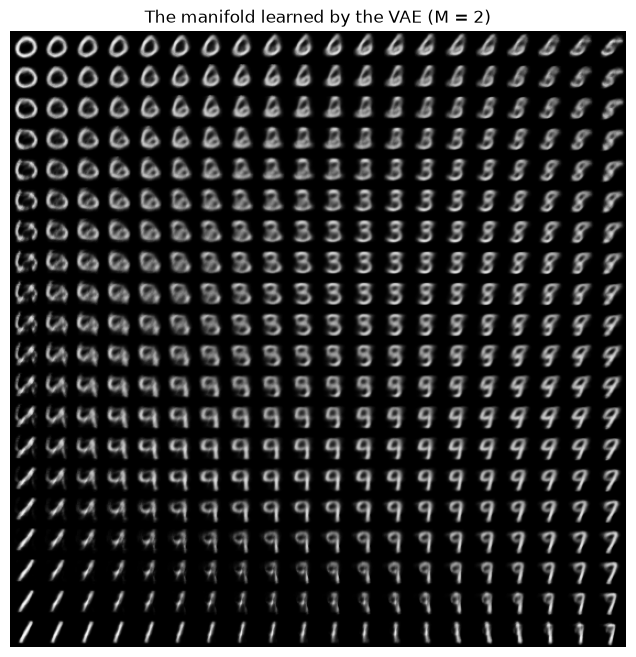

In [11]:
@torch.no_grad()
def plot_manifold(model, n=20, label=None, title="", figsize=(8, 8)):
    model.eval()
    u = torch.linspace(0.02, 0.98, n)
    grid = torch.special.ndtri(u)  # N(0, 1) quantiles on a uniform grid

    canvas = np.zeros((28 * n, 28 * n))
    for i, zi in enumerate(grid):
        z = torch.stack([zi.repeat(n), grid], dim=1)  # (n, 2)
        y = None
        if label is not None:
            y = F.one_hot(torch.full((n,), label), 10).float()
        imgs = torch.sigmoid(model.decode(z, y)).view(n, 28, 28).numpy()
        for j in range(n):
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = imgs[j]

    plt.figure(figsize=figsize)
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()


plot_manifold(vae2, n=20, title="The manifold learned by the VAE (M = 2)")

Note the smooth transitions between digits: neighboring points of the latent space decode into similar pictures. Find on your picture the transition from sixes to zeros or from sevens to ones — the post points it out too.

## How the latent dimension affects quality

The post shows that a noticeable jump in quality happens between $M = 2$ and $M = 5$, and further growth of the dimension gives almost nothing. Let us check the first half of this claim: train a model with $M = 16$ and compare the samples.

epoch  1 | -ELBO  182.14 | recon  169.44 | KL  12.70


epoch  2 | -ELBO  127.62 | recon  108.09 | KL  19.52


epoch  3 | -ELBO  118.14 | recon   96.81 | KL  21.33


epoch  4 | -ELBO  114.40 | recon   92.48 | KL  21.91


epoch  5 | -ELBO  112.13 | recon   89.86 | KL  22.27


epoch  6 | -ELBO  110.61 | recon   88.10 | KL  22.51


epoch  7 | -ELBO  109.61 | recon   86.92 | KL  22.69


epoch  8 | -ELBO  108.72 | recon   85.89 | KL  22.83


epoch  9 | -ELBO  108.03 | recon   85.10 | KL  22.94


epoch 10 | -ELBO  107.52 | recon   84.49 | KL  23.03


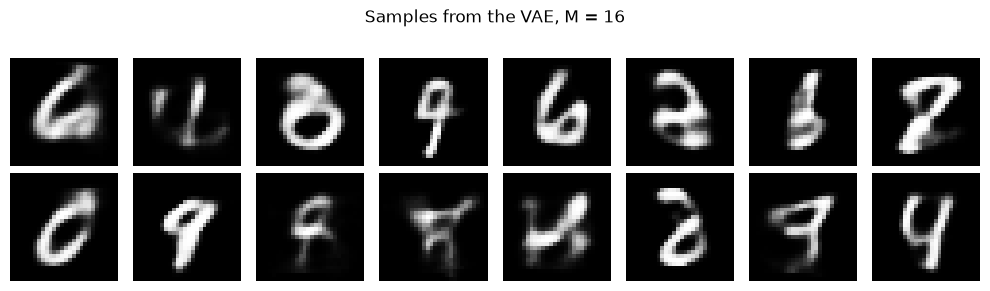

In [12]:
vae16 = VAE(latent_dim=16).to(device)
train(vae16, epochs=10)

show_grid(sample_from_prior(vae16, n=16), nrow=2, ncol=8,
          title="Samples from the VAE, M = 16", figsize=(10, 3))

The samples should become noticeably more meaningful: a two-dimensional latent is simply not enough to encode the full variety of handwritten digits.

## CVAE: conditioning on the class

Now let us learn to generate not "some" digit but a chosen one. As the post says, at the implementation level this is done extremely simply: we concatenate the encoder and decoder inputs with the one-hot vector of the label — this is exactly what we introduced `cond_dim` for.

The model is trained on all classes at once and its weights are shared — this is not the same as ten independent VAEs.

In [13]:
cvae = VAE(latent_dim=2, cond_dim=10).to(device)
train(cvae, epochs=10, conditional=True)

epoch  1 | -ELBO  192.80 | recon  185.45 | KL   7.34


epoch  2 | -ELBO  149.55 | recon  145.09 | KL   4.45


epoch  3 | -ELBO  143.04 | recon  138.75 | KL   4.29


epoch  4 | -ELBO  140.46 | recon  136.18 | KL   4.28


epoch  5 | -ELBO  138.86 | recon  134.56 | KL   4.29


...

epoch  7 | -ELBO  136.73 | recon  132.38 | KL   4.34


epoch  8 | -ELBO  135.93 | recon  131.57 | KL   4.36


epoch  9 | -ELBO  135.30 | recon  130.92 | KL   4.37


epoch 10 | -ELBO  134.74 | recon  130.33 | KL   4.41


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=784, bias=True)
  )
)

### Generating a chosen digit

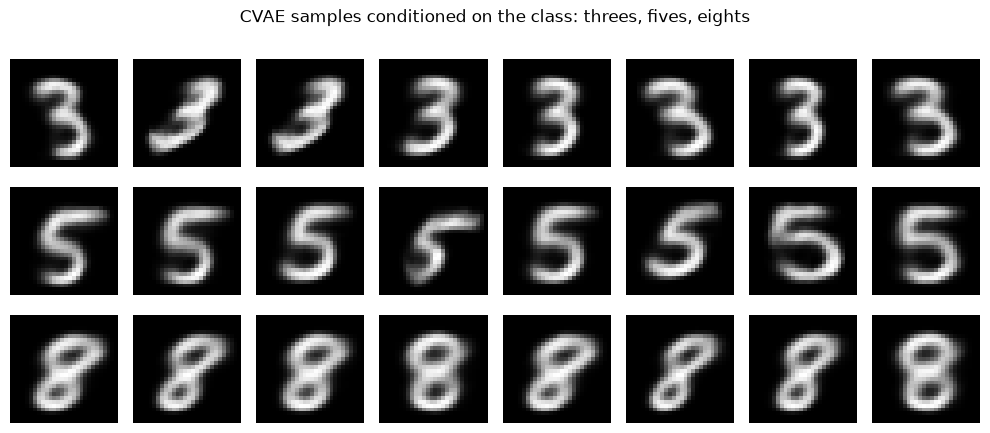

In [14]:
rows = [sample_from_prior(cvae, n=8, label=digit) for digit in [3, 5, 8]]
show_grid(torch.cat(rows), nrow=3, ncol=8,
          title="CVAE samples conditioned on the class: threes, fives, eights", figsize=(10, 4.5))

The quality of each individual digit is noticeably higher than that of the unconditional VAE with the same two-dimensional latent: the model no longer needs to spend the latent space on telling classes apart — the class is given to it explicitly. The latent now encodes only the "handwriting": slant, thickness, shape.

### The latent space of the CVAE

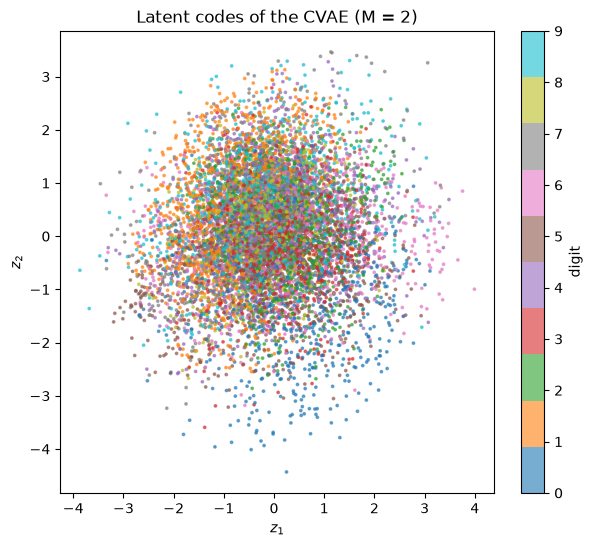

In [15]:
latent_scatter(cvae, conditional=True, title="Latent codes of the CVAE (M = 2)")

The per-class clusters are gone — instead there is a shapeless cloud. This is exactly the picture shown in the post, and it should not be alarming: each digit now has its own prior $p(z \mid y) = \mathcal{N}(0, I)$, and it is the condition $y$, not the latent, that separates the classes.

Let us make sure of this by plotting the manifold for a fixed class:

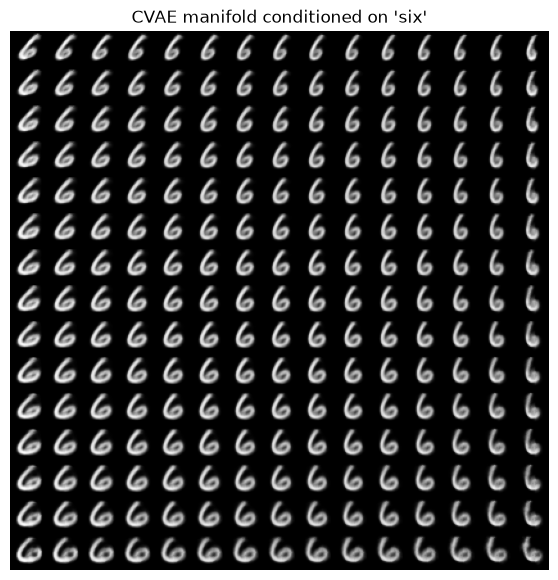

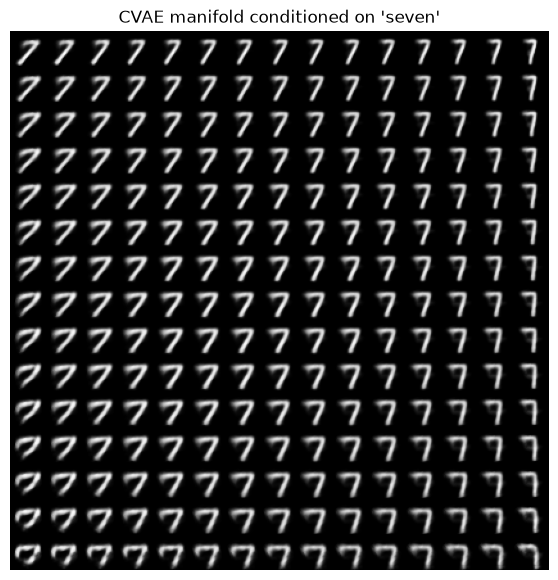

In [16]:
plot_manifold(cvae, n=15, label=6, title="CVAE manifold conditioned on 'six'", figsize=(7, 7))
plot_manifold(cvae, n=15, label=7, title="CVAE manifold conditioned on 'seven'", figsize=(7, 7))

The same region of the latent space decodes into different digits under different conditions, while within one class the latent smoothly varies the style.

## Exercises

**Exercise 1 (the main one).** Train a model with `beta=0`, i.e. dropping the KL term from the loss — you get a plain autoencoder. Plot its reconstructions and samples from $\mathcal{N}(0, I)$.

You will see that the reconstructions got *better* (nothing constrains the model anymore), while the samples from the prior turned into garbage. This is exactly the situation described in the post for VQ-VAE: without the regularization term, the distribution of the codes is not pulled toward the prior in any way, and one cannot sample from it. Plot `latent_scatter` for this model and see where the codes have drifted and what their scale is.

**Exercise 2.** Try `beta=4` ($\beta$-VAE). How does the balance between reconstruction quality and the "correctness" of the latent space change? Compare the `recon` and `KL` values in the training logs.

**Exercise 3.** Reproduce the post's picture about the latent space dimension in full: train models with $M \in \{2, 5, 10, 20\}$ and display samples from each side by side. Does the main jump really happen between 2 and 5?

**Exercise 4.** Replace the Bernoulli decoder with a Gaussian one with fixed variance: the reconstruction loss becomes a sum of squared errors (see the Gaussian decoder formula in the post). What happens to the pictures? Hint: $\sigma^2$ implicitly acts as a weight $\beta$ in front of the KL term.

**Exercise 5.** Condition the CVAE not on the class label but on the top half of the image (the post mentions that $y$ can be an arbitrary tensor). The model should learn to complete the bottom half of the digit. What needs to change? Only `cond_dim` and what you concatenate — the rest of the implementation stays the same.